# 05 · Forecasting

Estacionariedad (ADF/KPSS) y pronóstico con ARIMA/Prophet, validado con backtesting.

In [1]:
import sys
sys.path.append("..")

from src import utils

En este notebook se analiza si es posible predecir el comportamiento futuro de una canción en los charts de Spotify a partir de su serie temporal de streams diarios. Para esto, se trabaja con la canción **“Tusa”** en Argentina y se evalúa si la serie presenta condiciones razonables para aplicar modelos de forecasting.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RUTA = "../data/charts_argentina.csv"

df_ar = pd.read_csv(RUTA, parse_dates=["date"])
df_ar.head()

,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,24K Magic,34,2017-01-01,Bruno Mars,https://open.spotify.com/track/6b8Be6ljOzmkOmF...,Argentina,top200,MOVE_DOWN,58801.0
2,CAN'T STOP THE FEELING! (Original Song from Dr...,35,2017-01-01,Justin Timberlake,https://open.spotify.com/track/6JV2JOEocMgcZxY...,Argentina,top200,MOVE_UP,56170.0
3,Fuego,36,2017-01-01,Juanes,https://open.spotify.com/track/0mwPE0lPOgnWf2b...,Argentina,top200,MOVE_UP,55902.0
4,Bobo,37,2017-01-01,J Balvin,https://open.spotify.com/track/7AtlMCIauSQZqiX...,Argentina,top200,MOVE_UP,55360.0


In [3]:
CANCION = "Tusa"
ARTISTA = "KAROL G, Nicki Minaj"

serie_tusa = utils.construir_serie(
    df_ar,
    {
        "title": CANCION,
        "artist": ARTISTA,
        "region": "Argentina",
        "chart": "top200",
        "valor": "streams",
        "agregado": "sum"
    }
)

print(f"Cantidad de muestras: {len(serie_tusa)}")
print(f"Fecha inicial: {serie_tusa.index.min().date()}")
print(f"Fecha final: {serie_tusa.index.max().date()}")

serie_tusa.head()

Cantidad de muestras: 566
Fecha inicial: 2019-11-11
Fecha final: 2021-07-24


date
2019-11-11    29708.0
2019-11-12    33750.0
2019-11-13    36935.0
2019-11-14    41342.0
2019-11-15    60945.0
Name: streams, dtype: float64

La serie seleccionada corresponde a los streams diarios de **“Tusa”** en Argentina dentro del chart `top200`. La serie contiene **566 observaciones**, desde el 11 de noviembre de 2019 hasta el 24 de julio de 2021. Esta será la señal base para evaluar si es posible realizar predicción temporal.

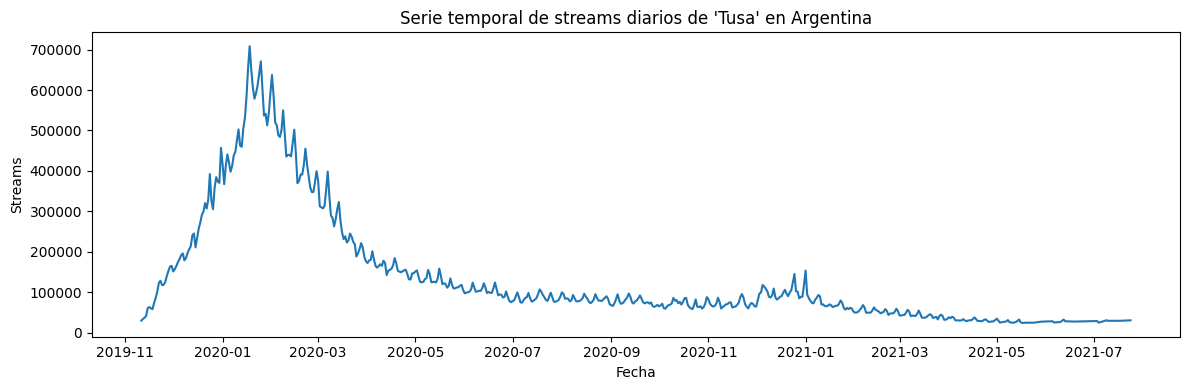

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(serie_tusa.index, serie_tusa.values)
plt.title("Serie temporal de streams diarios de 'Tusa' en Argentina")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.tight_layout()
plt.show()

Para evaluar la capacidad predictiva, se separa la serie temporal en dos partes: un conjunto de entrenamiento y un conjunto de test. El modelo se ajusta con los datos históricos y luego se evalúa sobre los últimos 30 días, que no se utilizan durante el entrenamiento.

In [5]:
horizonte = 30

train = serie_tusa.iloc[:-horizonte]
test = serie_tusa.iloc[-horizonte:]

print(f"Muestras entrenamiento: {len(train)}")
print(f"Muestras test: {len(test)}")
print(f"Inicio test: {test.index.min().date()}")
print(f"Fin test: {test.index.max().date()}")

Muestras entrenamiento: 536
Muestras test: 30
Inicio test: 2021-04-30
Fin test: 2021-07-24


El conjunto de test corresponde a los últimos **30 días** disponibles de la serie, desde el 30 de abril de 2021 hasta el 24 de julio de 2021. Este tramo se reserva para evaluar si el modelo logra anticipar correctamente la evolución final de la canción.

Como primer punto de comparación, se utiliza un modelo naive. Este modelo predice todos los valores futuros usando el último valor observado en el conjunto de entrenamiento. Aunque es muy simple, sirve como baseline para evaluar si modelos más complejos realmente aportan una mejora.

In [6]:
ultimo_valor_train = train.iloc[-1]

pred_naive = pd.Series(
    [ultimo_valor_train] * len(test),
    index=test.index
)

print(f"Último valor del entrenamiento: {ultimo_valor_train:,.0f}")
pred_naive.head()

Último valor del entrenamiento: 27,999


date
2021-04-30    27999.0
2021-05-01    27999.0
2021-05-02    27999.0
2021-05-03    27999.0
2021-05-07    27999.0
dtype: float64

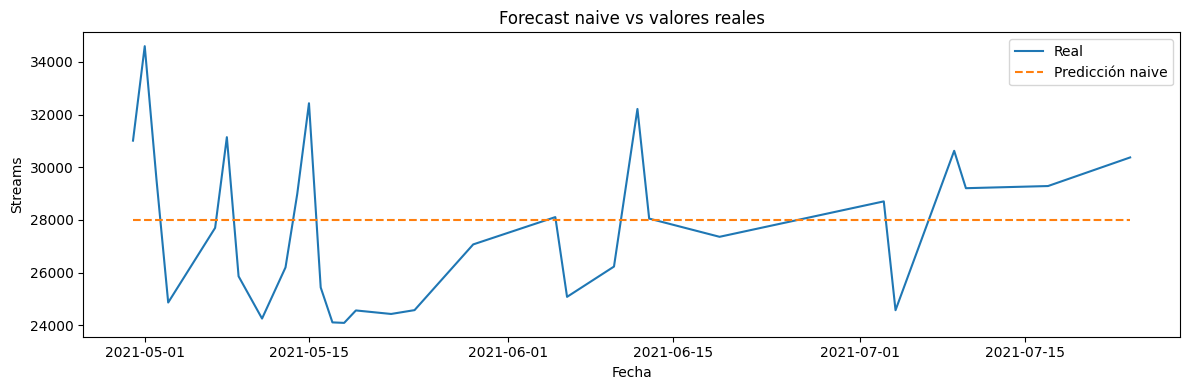

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Real")
plt.plot(pred_naive.index, pred_naive.values, label="Predicción naive", linestyle="--")
plt.title("Forecast naive vs valores reales")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.legend()
plt.tight_layout()
plt.show()

El modelo naive genera una predicción constante, igual al último valor observado en el conjunto de entrenamiento. Esto sirve como referencia inicial, pero no captura subidas, bajadas ni cambios de tendencia dentro del período de test.

In [8]:
def calcular_metricas(y_real, y_pred):
    mae = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

metricas_naive = calcular_metricas(test, pred_naive)

metricas_naive

{'MAE': np.float64(2464.6),
 'RMSE': np.float64(2883.691210930879),
 'MAPE (%)': np.float64(8.992894581353404)}

El modelo naive obtiene un MAE de aproximadamente **2.465 streams**, un RMSE de aproximadamente **2.884 streams** y un MAPE de **8,99%**. Esto significa que, en promedio, la predicción se desvía cerca de un 9% respecto de los valores reales del conjunto de test. Este resultado sirve como baseline para comparar modelos más elaborados.

Como segundo modelo simple, se utiliza una media móvil de los últimos 7 valores observados en el entrenamiento. Este enfoque suaviza fluctuaciones puntuales y permite construir una predicción constante basada en el comportamiento reciente de la serie.

In [9]:
valor_media_movil_7 = train.tail(7).mean()

pred_ma7 = pd.Series(
    [valor_media_movil_7] * len(test),
    index=test.index
)

print(f"Promedio de los últimos 7 valores del entrenamiento: {valor_media_movil_7:,.0f}")
pred_ma7.head()

Promedio de los últimos 7 valores del entrenamiento: 29,045


date
2021-04-30    29045.285714
2021-05-01    29045.285714
2021-05-02    29045.285714
2021-05-03    29045.285714
2021-05-07    29045.285714
dtype: float64

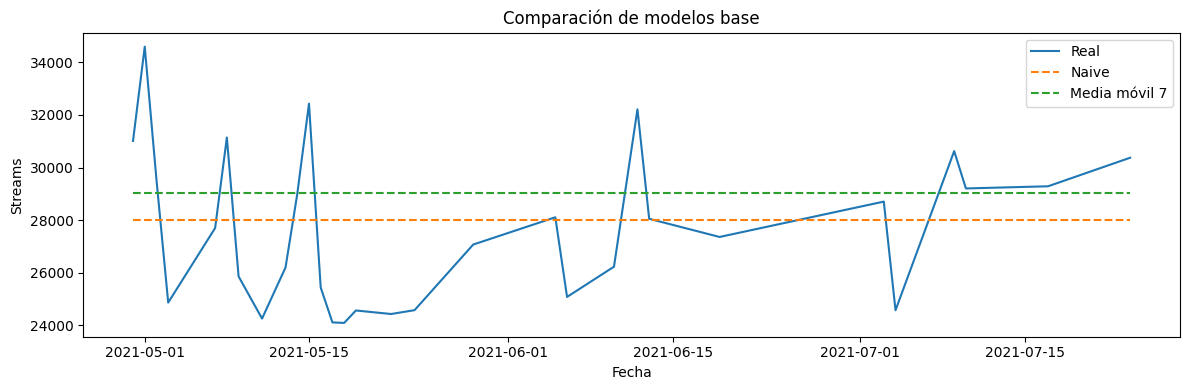

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Real")
plt.plot(pred_naive.index, pred_naive.values, label="Naive", linestyle="--")
plt.plot(pred_ma7.index, pred_ma7.values, label="Media móvil 7", linestyle="--")
plt.title("Comparación de modelos base")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
metricas_ma7 = calcular_metricas(test, pred_ma7)

comparacion_metricas = pd.DataFrame({
    "Naive": metricas_naive,
    "Media móvil 7": metricas_ma7
})

comparacion_metricas

,Naive,Media móvil 7
MAE,2464.600000,2690.228571
RMSE,2883.691211,3172.397849
MAPE (%),8.992895,10.131031


Al comparar ambos modelos base, el modelo **naive** obtiene mejores resultados que la media móvil de 7 valores: presenta menor MAE, menor RMSE y menor MAPE. Esto indica que, para este tramo final de la serie, repetir el último valor observado fue una estrategia más precisa que usar el promedio reciente. Esto puede ocurrir porque la serie se encuentra en una etapa relativamente estable y de baja popularidad.

Como modelo de forecasting más específico para series temporales, se prueba un modelo ARIMA. Este tipo de modelo combina componentes autorregresivas, diferenciación y errores pasados para generar predicciones. En este caso se utiliza una especificación simple, ARIMA(1,1,1), como primera aproximación.

In [12]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arima = ARIMA(train, order=(1, 1, 1))
resultado_arima = modelo_arima.fit()

pred_arima = resultado_arima.forecast(steps=len(test))
pred_arima.index = test.index

pred_arima.head()

C:\Users\tatug\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\tatug\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\tatug\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


date
2021-04-30    28154.508007
2021-05-01    28090.559125
2021-05-02    28116.856546
2021-05-03    28106.042372
2021-05-07    28110.489437
Name: predicted_mean, dtype: float64

El modelo ARIMA(1,1,1) genera una predicción no completamente constante, pero con variaciones suaves alrededor de los valores recientes de la serie. A continuación se compara visualmente esta predicción con los valores reales del conjunto de test.

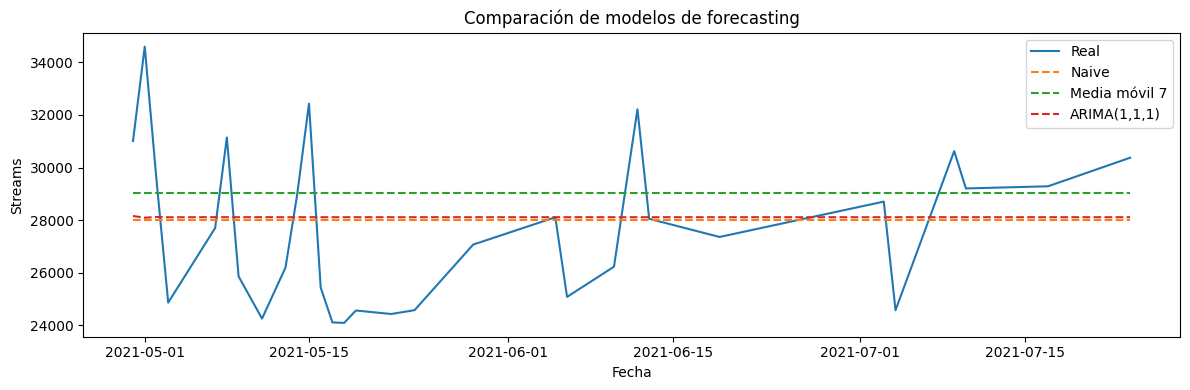

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Real")
plt.plot(pred_naive.index, pred_naive.values, label="Naive", linestyle="--")
plt.plot(pred_ma7.index, pred_ma7.values, label="Media móvil 7", linestyle="--")
plt.plot(pred_arima.index, pred_arima.values, label="ARIMA(1,1,1)", linestyle="--")
plt.title("Comparación de modelos de forecasting")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
metricas_arima = calcular_metricas(test, pred_arima)

comparacion_metricas = pd.DataFrame({
    "Naive": metricas_naive,
    "Media móvil 7": metricas_ma7,
    "ARIMA(1,1,1)": metricas_arima
})

comparacion_metricas

,Naive,Media móvil 7,"ARIMA(1,1,1)"
MAE,2464.600000,2690.228571,2474.988977
RMSE,2883.691211,3172.397849,2897.376854
MAPE (%),8.992895,10.131031,9.065461


Al comparar los tres modelos, el modelo **naive** obtiene el menor error en las tres métricas consideradas: MAE, RMSE y MAPE. El modelo ARIMA(1,1,1) presenta resultados muy similares, pero no logra mejorar al baseline naive. Por su parte, la media móvil de 7 valores obtiene el peor desempeño relativo.

Esto sugiere que, en el tramo final de la serie, la canción se encontraba en una etapa relativamente estable, donde repetir el último valor observado resultó suficiente para obtener una predicción competitiva. En este caso, un modelo más complejo como ARIMA no aporta una mejora clara frente a un baseline simple.

En este notebook se evaluó la posibilidad de predecir el comportamiento futuro de **“Tusa”** en Argentina a partir de su serie temporal de streams diarios. Para eso, se separó la serie en entrenamiento y test, reservando las últimas 30 observaciones para evaluación.

Se compararon tres enfoques de forecasting: un modelo naive, una media móvil de 7 observaciones y un modelo ARIMA(1,1,1). Los resultados muestran que el modelo naive obtuvo el mejor desempeño, con un MAPE aproximado de **8,99%**, seguido muy de cerca por ARIMA, con un MAPE aproximado de **9,07%**.

Esto indica que, para el tramo final analizado, la serie podía predecirse razonablemente bien con un modelo muy simple. Sin embargo, también muestra que la predicción de canciones en charts depende mucho de la etapa del ciclo de vida: en momentos de alta volatilidad, crecimiento abrupto o caída rápida, probablemente sería más difícil obtener buenas predicciones con modelos simples.

En conjunto, este análisis permite responder que sí es posible aplicar técnicas de forecasting sobre la serie temporal de una canción, aunque la utilidad del modelo depende del comportamiento específico de la señal y del período que se quiera predecir.